In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from scipy.spatial.distance import pdist

In [3]:
training_configs = np.load("LJ13_configs.npy")

In [4]:
com = training_configs.mean(axis=1, keepdims=True)

training_configs_centered = training_configs - com

In [5]:
training_configs_centered_tensor = torch.tensor(training_configs_centered, dtype=torch.float32)

print(training_configs_centered_tensor.shape)

torch.Size([24994, 13, 3])


In [6]:
class MessageMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [7]:
class FeatureMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class CoordMLP(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2*hidden_dim + 2, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
        )

        torch.nn.init.xavier_uniform_(
            self.net[-1].weight,
            gain=0.001
        )

        torch.nn.init.zeros_(
            self.net[-1].bias
        )

    def forward(self, x):
        return self.net(x)

In [9]:
class EGNNLayer(nn.Module):

    def __init__(self, hidden_dim=64):
        super().__init__()

        self.message_mlp = MessageMLP(hidden_dim)

        self.feature_mlp = FeatureMLP(hidden_dim)

        self.coord_mlp = CoordMLP(hidden_dim)

    def forward(self, x, h, log_sigma):

        N = x.shape[1]

        diff = x[:,:,None,:] - x[:,None,:,:]
        dist2 = (diff**2).sum(dim=-1, keepdim=True)

        hi = h[:,:,None,:]
        hi = hi.expand(-1,-1,N,-1)

        hj = h[:,None,:,:]
        hj = hj.expand(-1,N,-1,-1)

        log_sigma_pair = log_sigma[:,None,None,:]
        log_sigma_pair = log_sigma_pair.expand(-1,N,N,-1)

        message_input = torch.cat([hi, hj, dist2, log_sigma_pair], dim=-1)

        messages = self.message_mlp(message_input)

        agg_messages = messages.sum(dim=2)

        feature_input = torch.cat([h, agg_messages], dim=-1)

        feature_update = self.feature_mlp(feature_input)

        h_new = h + feature_update

        coord_weights = self.coord_mlp(message_input)

        coord_update = diff * coord_weights

        delta_x = coord_update.sum(dim=2)

        delta_x = delta_x / x.shape[1]

        x_new = x + delta_x

        return x_new, h_new, delta_x

    

In [10]:
class ScoreNetwork(nn.Module):

    def __init__(
        self,
        hidden_dim=64,
        num_layers=3
    ):
        super().__init__()

        self.embedding = nn.Linear(1, hidden_dim)

        self.layers = nn.ModuleList(
            [
                EGNNLayer(hidden_dim)
                for _ in range(num_layers)
            ]
        )


    def forward(self, x, log_sigma):

        atom_features = torch.ones(x.shape[0], x.shape[1], 1)

        h = self.embedding(atom_features)

        f_pred = torch.zeros_like(x)

        for layer in self.layers:

            x, h, delta_x = layer(x, h, log_sigma)

            f_pred = f_pred + delta_x

        f_pred = f_pred - f_pred.mean(dim=1, keepdim=True)


        return f_pred


In [11]:
X = training_configs_centered.reshape(training_configs_centered.shape[0],39)
X = torch.tensor(X, dtype=torch.float32)

X_np = X.cpu().numpy()

sigma_max = pdist(X_np).max()
sigma_min = 0.01

print("sigma_max:", sigma_max)

sigma_max: 6.440439591617135


In [12]:
def get_sigma(t):

    return sigma_min * (sigma_max/sigma_min)**t

In [13]:
def g(t):

    sigma = get_sigma(t)

    return (sigma * np.sqrt(2*np.log(sigma_max/sigma_min)))

In [14]:
def train_model(
  optimizer_name="Adam",
  lr = 1e-4,
  batch_size = 100,
  width = 64,
  depth = 3,
  num_epochs = 600   
):
    dataset = TensorDataset(training_configs_centered_tensor)

    loader = DataLoader(dataset,batch_size=batch_size,shuffle=True)

    model = ScoreNetwork(hidden_dim=width,num_layers=depth)

    if optimizer_name == "Adam":
        
        optimizer=optim.Adam(
            model.parameters(),
            lr=lr
        )
    else:

        optimizer = optim.SGD(
            model.parameters(),
            lr=lr
        )
    

    loss_history = []

    for epoch in range(num_epochs):
        
        epoch_loss = 0.0

        for (x_batch,) in loader:
            
            batch_size_current = x_batch.shape[0]
            
            t = torch.rand(batch_size_current,1)

            sigma = get_sigma(t)

            sigma_expanded = sigma.view(-1,1,1)

            z = torch.randn_like(x_batch)

            z = z - z.mean(dim=1, keepdim=True)
            
            x_noisy = x_batch + sigma_expanded * z

            log_sigma = torch.log(sigma)
            
            target = -z  

            f_pred = model(x_noisy, log_sigma)

            loss_per_sample = ((f_pred - target) ** 2).sum(dim=(1,2))

            #weights = sigma.squeeze() ** 2

            loss = (loss_per_sample).mean()

            optimizer.zero_grad()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            optimizer.step()
            
            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(loader)
        loss_history.append(avg_loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | Loss = {avg_loss:.6f}")

    return model, loss_history

In [16]:
model, loss_history = train_model()

Epoch    0 | Loss = 25.015805
Epoch   10 | Loss = 15.540078
Epoch   20 | Loss = 14.457292
Epoch   30 | Loss = 13.968819
Epoch   40 | Loss = 13.618592
Epoch   50 | Loss = 13.556765
Epoch   60 | Loss = 13.058388
Epoch   70 | Loss = 13.007499
Epoch   80 | Loss = 12.967538
Epoch   90 | Loss = 12.830750
Epoch  100 | Loss = 12.689741
Epoch  110 | Loss = 12.666942
Epoch  120 | Loss = 12.505568
Epoch  130 | Loss = 12.560448
Epoch  140 | Loss = 12.720959
Epoch  150 | Loss = 12.539285
Epoch  160 | Loss = 12.502752
Epoch  170 | Loss = 12.553208
Epoch  180 | Loss = 12.574902
Epoch  190 | Loss = 12.496820
Epoch  200 | Loss = 12.300822
Epoch  210 | Loss = 12.220660
Epoch  220 | Loss = 12.561314
Epoch  230 | Loss = 12.385658
Epoch  240 | Loss = 12.232280
Epoch  250 | Loss = 12.379372
Epoch  260 | Loss = 12.384553
Epoch  270 | Loss = 12.237653
Epoch  280 | Loss = 12.299810
Epoch  290 | Loss = 12.402484
Epoch  300 | Loss = 12.301196
Epoch  310 | Loss = 12.247299
Epoch  320 | Loss = 12.331019
Epoch  330

In [17]:
torch.save(model.state_dict(), "lj13_f_theta_2.pth")

Text(0, 0.5, 'Loss')

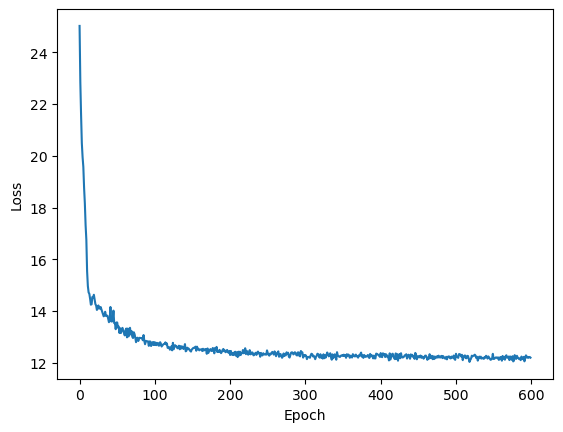

In [18]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")

The loss is now roughly 12.2 (against a baseline of 36, since it is now in the COM-free subspace)
and it captures roughly 66% of the noise variance as opposed to 61% as in the previous model

In [19]:
model.eval()

x = training_configs_centered_tensor[0:1]

for sigma_value in [0.01, 0.1, 1.0, 6.44]:

    sigma = torch.tensor([[sigma_value]])

    noise = torch.randn_like(x)
    noise = noise - noise.mean(dim=1, keepdim=True)

    x_noisy = x + sigma.view(1, 1, 1) * noise
    log_sigma = torch.log(sigma)

    with torch.no_grad():
        f_pred = model(x_noisy, log_sigma)

    score_pred = f_pred / sigma.view(1, 1, 1)
    score_true = -noise / sigma.view(1, 1, 1)

    cosine = torch.nn.functional.cosine_similarity(
        score_pred.flatten(),
        score_true.flatten(),
        dim=0
    )

    magnitude_ratio = score_pred.norm() / score_true.norm()

    print(
        f"sigma = {sigma_value:5.2f} | "
        f"cosine = {cosine.item():.4f} | "
        f"magnitude ratio = {magnitude_ratio.item():.4f}"
    )

sigma =  0.01 | cosine = 0.2925 | magnitude ratio = 0.2620
sigma =  0.10 | cosine = 0.8824 | magnitude ratio = 0.9060
sigma =  1.00 | cosine = 0.9112 | magnitude ratio = 0.8939
sigma =  6.44 | cosine = 0.9937 | magnitude ratio = 0.9795


Although the loss shows improvement, the network still struggles at small sigma (such as 0.01) 

In [15]:
model = ScoreNetwork(hidden_dim=64, num_layers=3)

model.load_state_dict(torch.load("lj13_f_theta_2.pth"))

model.eval()

ScoreNetwork(
  (embedding): Linear(in_features=1, out_features=64, bias=True)
  (layers): ModuleList(
    (0-2): 3 x EGNNLayer(
      (message_mlp): MessageMLP(
        (net): Sequential(
          (0): Linear(in_features=130, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): SiLU()
        )
      )
      (feature_mlp): FeatureMLP(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
        )
      )
      (coord_mlp): CoordMLP(
        (net): Sequential(
          (0): Linear(in_features=130, out_features=64, bias=True)
          (1): SiLU()
          (2): Linear(in_features=64, out_features=64, bias=True)
          (3): SiLU()
          (4): Linear(in_features=64, out_features=1, bias=True)
        )
      )
    )
  )
)

In [16]:
def predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
):

    model.eval()

    x = torch.randn(n_samples, 13, 3)
    x = x - x.mean(dim=1, keepdim=True)
    x = x * sigma_max

    dt = 1.0 / n_steps
    sqrt_dt = np.sqrt(dt)


    with torch.no_grad():

        for i in range(n_steps):

            t = 1 - i / n_steps

            t_tensor = torch.full((n_samples,1), t)

            sigma = get_sigma(t_tensor)
            log_sigma = torch.log(sigma)

            g_val = g(t_tensor).view(-1, 1, 1)

            f_pred = model(x, log_sigma)

            score = f_pred / sigma.view(-1, 1, 1)

            if torch.isnan(score).any():
                    print(f"NaN in score at step {i}, t={t:.4f}, sigma={sigma[0].item():.4f}")
                    
                    break

            noise = torch.randn_like(x)

            noise = noise - noise.mean(dim=1, keepdim=True)

            x = (x + (g_val**2) * score * dt + g_val * sqrt_dt * noise)

            
            if torch.isnan(x).any():
                    print(f"NaN in x (predictor) at step {i}")
                    break

            for _ in range(n_corrector):

                f_pred = model(x, log_sigma)

                score = f_pred / sigma.view(-1, 1, 1)

                noise = torch.randn_like(x)

                noise = noise - noise.mean(dim=1, keepdim=True)

                score_norm = torch.norm(score.reshape(n_samples, -1), dim=1).mean()

                noise_norm = torch.norm(noise.reshape(n_samples,-1), dim=1).mean()

                if score_norm.item() == 0.0 or torch.isnan(score_norm):
                        print(f"score_norm degenerate at step {i}: {score_norm.item()}")
                        break

                eps = (2 * (snr * noise_norm / score_norm)**2)
                #eps = torch.clamp(eps, max=0.05)       

                x = (x + eps * score + torch.sqrt(2*eps) * noise)

                if torch.isnan(x).any():
                        print(f"NaN in x (corrector) at step {i}")
                        break


    return x

In [17]:
samples = predictor_corrector_sampler(
    model,
    n_samples=1000,
    n_steps=1000,
    n_corrector=1,
    snr=0.16
)

In [18]:
print("NaNs present:", torch.isnan(samples).any().item())
print("Infs present:", torch.isinf(samples).any().item())
print("Sample range:", samples.min().item(), samples.max().item())
print("COM check:", samples.mean(dim=1).abs().max().item())

NaNs present: False
Infs present: False
Sample range: -1.2142521142959595 1.1933451890945435
COM check: 4.56434008810902e-06


In [19]:
def lj_energy(coords):

    N = coords.shape[0]

    energy = 0.0

    for i in range(N):
        for j in range(i + 1, N):

            r = torch.norm(coords[i] - coords[j])

            inv_r6 = (1.0 / r) ** 6
            inv_r12 = inv_r6 ** 2

            energy += 4 * (inv_r12 - inv_r6)

    return energy

In [20]:
generated_energies = []

for sample in samples:

    E = lj_energy(sample)

    generated_energies.append(E.item())

generated_energies = np.array(generated_energies)

In [21]:
training_energies = []

for sample in training_configs_centered_tensor:

    E = lj_energy(sample)

    training_energies.append(E.item())

training_energies = np.array(training_energies)

In [22]:
print("Training")
print(training_energies.min())
print(training_energies.max())
print(training_energies.mean())

print()

print("Generated")
print(generated_energies.min())
print(generated_energies.max())
print(generated_energies.mean())

Training
-43.76762771606445
-40.26786804199219
-42.526261944498756

Generated
-43.33226013183594
-36.55852127075195
-42.04655184173584


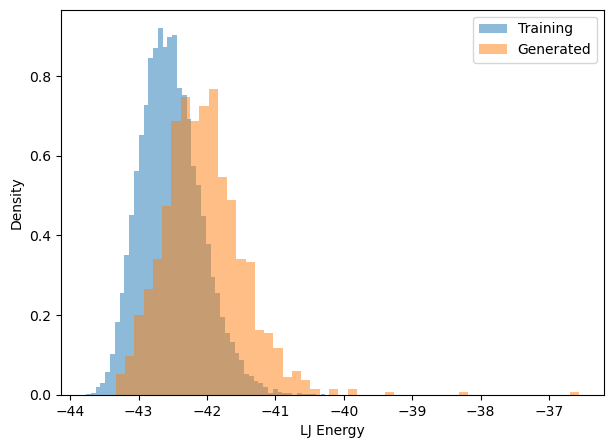

In [23]:
plt.figure(figsize=(7,5))

plt.hist(training_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Training")

plt.hist(generated_energies,
         bins=50,
         density=True,
         alpha=0.5,
         label="Generated")

plt.xlabel("LJ Energy")
plt.ylabel("Density")
plt.legend()
plt.show()

In [25]:
mean_U_generated = np.mean(generated_energies)
print("Mean U generated:", mean_U_generated)

Mean U generated: -42.04655184173584


In [26]:
U_min = -44.3268

T_eff_generated = (mean_U_generated - U_min) / (33 / 2)

print("Generated T_eff:", T_eff_generated)

Generated T_eff: 0.1381968580766156


The T_eff of the new model (with both 1/sigma parametrization and imposing a COM-free subspace) has reduced compared to the 0.1434 we measured for the previous model

In [27]:
def pairwise_distances(configs):

    distances = []

    for config in configs:

        for i in range(13):
            for j in range(i+1,13):

                r = torch.norm(config[i]-config[j])

                distances.append(r.item())

    return np.array(distances)

In [28]:
training_distances = pairwise_distances(training_configs_centered_tensor)

generated_distances = pairwise_distances(samples)

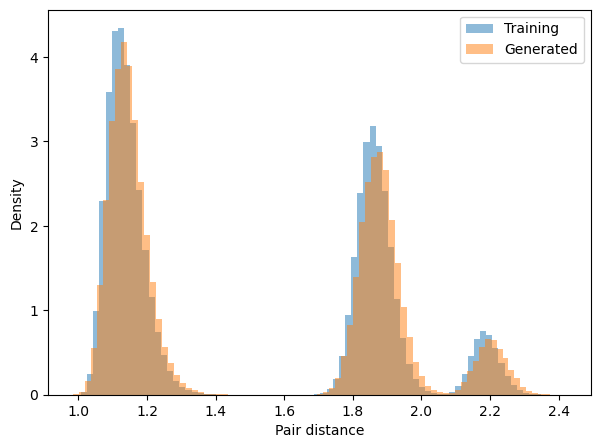

In [29]:
plt.figure(figsize=(7,5))

plt.hist(
    training_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Training"
)

plt.hist(
    generated_distances,
    bins=80,
    density=True,
    alpha=0.5,
    label="Generated"
)

plt.xlabel("Pair distance")
plt.ylabel("Density")
plt.legend()

plt.show()

In [33]:
import torch.nn.functional as F

true_norms = []
learned_norms = []
cosine_similarities = []
norm_percentage_differences = []

n_test = 500
Temp = 0.10
beta = 1.0 / Temp

for k in range(n_test):

    x = training_configs_centered_tensor[k].clone()
    x.requires_grad_(True)

    U = lj_energy(x)

    grad_U = torch.autograd.grad(U, x)[0]

    true_score = -beta * grad_U

    sigma = torch.tensor([[sigma_min]], dtype=torch.float32)
    log_sigma = torch.log(sigma)

    with torch.no_grad():
        f_pred = model(x.unsqueeze(0), log_sigma)[0]

        learned_score = f_pred / sigma_min


    true_norm = torch.norm(true_score)
    learned_norm = torch.norm(learned_score)

    true_norms.append(true_norm.item())
    learned_norms.append(learned_norm.item())


    cosine = F.cosine_similarity(true_score.flatten(), learned_score.flatten(), dim=0)

    cosine_similarities.append(cosine.item())

mean_true_norm = sum(true_norms) / len(true_norms)

mean_learned_norm = sum(learned_norms) / len(learned_norms)

mean_cosine = (sum(cosine_similarities) / len(cosine_similarities))

norm_percentage_difference = (abs(mean_learned_norm - mean_true_norm) / mean_true_norm * 100)


print("Mean true score norm:",
      mean_true_norm)

print("Mean learned score norm:",
      mean_learned_norm)

print("Mean cosine similarity:",
      mean_cosine)

print("Mean norm percentage difference:",
      norm_percentage_difference, "%")


Mean true score norm: 224.19168452453613
Mean learned score norm: 182.57132432556153
Mean cosine similarity: 0.9659170874357224
Mean norm percentage difference: 18.564631550560275 %


The mean learned norm has reduced from 23.9% to 18.5%